In [1]:
import os
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import torch.nn.functional as F

import cv2
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from sklearn.decomposition import PCA

In [2]:
label_path = r'6 dataset (160-2560, step=140)\masks (3 classes) (new)'
srez_path = r'6 dataset (160-2560, step=140)\initial images (new)'

In [3]:
label = cv2.imread(label_path + r"\output_00160.tif")[:, :, 0]
srez = cv2.imread(srez_path + r"\00160.png")[:, :, 0]

In [4]:
files = list(zip(os.listdir(label_path), os.listdir(srez_path)))
n = len(files)

num_classes = 2
image_list = []
target_list = []
for i, (l_p, s_p) in enumerate(files):
    label = cv2.imread(label_path + '/' + l_p)[:, :, 0]
    srez = cv2.imread(srez_path + '/' + s_p)[:, :, 0]

    c_x = srez.shape[0] // 2
    c_y = srez.shape[1] // 2
    w = label.shape[0] // 2
    h = label.shape[1] // 2
    crop_srez = srez[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]
    
    label[label == 2] = 0

    image_list.append(crop_srez)
    target_list.append(label)


In [5]:
class CoreDataset(torch.utils.data.Dataset):
    def __init__(self, labels, srez_list, transform=None):
        """
        labels: list of numpy arrays (H,W) или (H,W,1)
        srez_list: list of numpy arrays (H,W) или (H,W,1)
        transform: albumentations.Compose или любой кастомный трансформ
        """
        assert len(labels) == len(srez_list), "Labels and srez lists must have the same length"
        
        self.labels = labels
        self.srez_list = srez_list
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx].astype("float32")
        srez = self.srez_list[idx].astype(np.long)

        c_x = srez.shape[0] // 2
        c_y = srez.shape[1] // 2
        w = label.shape[0] // 2
        h = label.shape[1] // 2

        crop_srez = srez[(c_x - w):(c_x + w), (c_y - h):(c_y + h)]

    
        if self.transform:
            transformed = self.transform(image=crop_srez, target=label)
            crop_srez = transformed['image']
            label = transformed['target']

        crop_srez = np.expand_dims(crop_srez, axis=0)

        return {
            "image": crop_srez,  
            "target": label       
        }

In [6]:
class Decoder(nn.Module):
    def __init__(self, in_channels=256, num_classes=21):
        super().__init__()
        # 1. H/32 -> H/16
        in_ch = in_channels
        self.deconv1 = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(in_ch // 2)
        
        # 2. H/16 -> H/8
        self.deconv2 = nn.ConvTranspose2d(in_ch // 2, in_ch // 4, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(in_ch // 4)
        
        # 3. H/8 -> H/4
        self.deconv3 = nn.ConvTranspose2d(in_ch // 4, in_ch // 8, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(in_ch // 8)
        
        # 4. H/4 -> H / 2
        self.deconv4 = nn.ConvTranspose2d(in_ch // 8, in_ch // 16, kernel_size=4, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(in_ch // 16)

        self.deconv5 = nn.ConvTranspose2d(in_ch // 16, num_classes, kernel_size=4, stride=2, padding=1)

        self.num_classes = num_classes

    def forward(self, x):
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = F.relu(self.bn4(self.deconv4(x)))
        x = self.deconv5(x)  # logits без активации
        return x
    
    def reset(self):
            for m in self.modules():
                if hasattr(m, "reset_parameters"):
                    m.reset_parameters()

In [7]:
processor = SegformerImageProcessor(do_reduce_labels=True)
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
configuration = model.config

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("SegFormer Segmentation model")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

encoder = model.segformer
encoder.encoder.patch_embeddings[0].proj = nn.Conv2d(1, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))

total = sum(p.numel() for p in encoder.parameters())
trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print("Encoder")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

train_head = Decoder(in_channels = 256, num_classes = 1)
total = sum(p.numel() for p in train_head.parameters())
trainable = sum(p.numel() for p in train_head.parameters() if p.requires_grad)
print("Placeholder head")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

validation_head = Decoder(in_channels = 256, num_classes = 2)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegFormer Segmentation model
Total params: 3,752,694
Trainable params: 3,752,694
Encoder
Total params: 3,316,256
Trainable params: 3,316,256
Placeholder head
Total params: 697,297
Trainable params: 697,297


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 8
num_epochs = 100
learning_rate = 1e-3
val_epochs = 5

optimizer = torch.optim.AdamW(
        [{'params': encoder.parameters()},
         {'params': train_head.parameters()}],
        lr=learning_rate
    )

loss_MSE = torch.nn.MSELoss(reduction='sum')
loss_CE = torch.nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         
    factor=0.2,    
    patience=3,            
    min_lr=1e-8,
    threshold = 1e-3          
)

In [9]:
def compute_miou(predictions, targets, num_classes, ignore_index=255):
    preds = predictions.argmax(dim=1)  # [B, H, W]
    valid = (targets != ignore_index)
    
    # Маскируем
    preds = preds * valid + ignore_index * (~valid)
    targets = targets * valid + ignore_index * (~valid)
    
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        inter = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()
        if union > 0:
            ious.append(inter / union)
    
    return sum(ious) / len(ious) if ious else 0.0

In [10]:
def crop_4(image: np.ndarray, crop_size: int = 512):
    """
    Делит одно изображение (NumPy array) на 4 кропа заданного размера.

    Args:
        image (np.ndarray): массив [H, W] или [H, W, C]
        crop_size (int): размер кропа

    Returns:
        patches (list of np.ndarray): список из 4 кропов
    """
    if image.ndim == 2:
        H, W = image.shape
        C = None
    elif image.ndim == 3:
        H, W, C = image.shape
    else:
        raise ValueError("image должен быть [H, W] или [H, W, C]")

    if H < crop_size or W < crop_size:
        raise ValueError(f"Изображение слишком маленькое ({H}x{W}) для кропа {crop_size}x{crop_size}")

    # верхний левый
    patch1 = image[0:crop_size, 0:crop_size] if C is None else image[0:crop_size, 0:crop_size, :]
    # верхний правый
    patch2 = image[0:crop_size, W-crop_size:W] if C is None else image[0:crop_size, W-crop_size:W, :]
    # нижний левый
    patch3 = image[H-crop_size:H, 0:crop_size] if C is None else image[H-crop_size:H, 0:crop_size, :]
    # нижний правый
    patch4 = image[H-crop_size:H, W-crop_size:W] if C is None else image[H-crop_size:H, W-crop_size:W, :]

    return [patch1, patch2, patch3, patch4]

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def plot_pca_2d(pca_2d_embeddings, labels, epoch=None, title=None, 
                connect_pairs=False, view_markers=None):
    """
    Визуализация PCA [N, 2] с цветными метками
    
    Args:
        pca_2d_embeddings: np.array [N, 2] — координаты после PCA
        labels: list/array [N] — метки (например, ID изображений)
        connect_pairs: bool — соединять ли линии между view1/view2 одного изображения
        view_markers: dict — {'v1': 'o', 'v2': 'x'} для разных маркеров
    """
    plt.figure(figsize=(8, 6))
    
    # Цветовая схема: каждая уникальная метка — свой цвет
    unique_labels = np.unique(labels)
    color_map = plt.get_cmap('tab10', len(unique_labels))
    label_to_color = {lbl: color_map(i) for i, lbl in enumerate(unique_labels)}
    
    # Рисуем точки
    for i, (x, y) in enumerate(pca_2d_embeddings):
        lbl = labels[i]
        marker = 'o'
        
        # Если есть информация о view (например, '42_v1', '42_v2')
        if view_markers and isinstance(lbl, str):
            for view_key, marker_symbol in view_markers.items():
                if view_key in lbl:
                    marker = marker_symbol
                    break
        
        plt.scatter(x, y, c=[label_to_color[lbl]], marker=marker, 
                   s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
    
    # Соединяем пары одного изображения (для DINO: view1 ↔ view2)
    if connect_pairs:
        # Ожидаем метки вида '42_v1', '42_v2'
        img_to_idx = {}
        for i, lbl in enumerate(labels):
            if isinstance(lbl, str) and '_' in lbl:
                img_id = lbl.rsplit('_', 1)[0]  # '42_v1' → '42'
                if img_id not in img_to_idx:
                    img_to_idx[img_id] = []
                img_to_idx[img_id].append(i)
        
        for img_id, idx_list in img_to_idx.items():
            if len(idx_list) == 2:  # ровно 2 views
                i1, i2 = idx_list
                x1, y1 = pca_2d_embeddings[i1]
                x2, y2 = pca_2d_embeddings[i2]
                plt.plot([x1, x2], [y1, y2], 'gray', linewidth=0.8, alpha=0.3)
    
    # Оформление
    plt.xlabel('PC1', fontsize=10)
    plt.ylabel('PC2', fontsize=10)
    plt.title(title or f'PCA Visualization | Epoch {epoch}' if epoch else 'PCA Visualization', 
              fontsize=12, pad=15)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    return plt.gcf()

In [12]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(),
])
val_transform = A.Normalize()

train_target = [crop_4(p) for p in target_list[:32]] 
train_image = [crop_4(p) for p in image_list[:32]] 

train_target = [item for sublist in train_target for item in sublist]
train_image = [item for sublist in train_image for item in sublist]

train_dataset = CoreDataset(train_target, train_image, transform)

val_target = [crop_4(p) for p in target_list[32:]] 
val_image = [crop_4(p) for p in image_list[32:]] 

val_target = [item for sublist in val_target for item in sublist]
val_image = [item for sublist in val_image for item in sublist]

validation_dataset = CoreDataset(val_target, val_image, val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [13]:
class Masker:
    def __init__(self, patch_size, mask_chance):
        self.patch_size = patch_size
        self.mask_chance = mask_chance
    
    def __call__(self, image):
        B, C, H, W = image.shape

        pad_h = (self.patch_size - H % self.patch_size) % self.patch_size
        pad_w = (self.patch_size - W % self.patch_size) % self.patch_size

        if pad_h != 0 or pad_w != 0:
            image = F.pad(image, (0, pad_w, 0, pad_h))

        _, _, H_pad, W_pad = image.shape

        h = H_pad // self.patch_size
        w = W_pad // self.patch_size

        mean_pixel = image.mean()

        mask = torch.rand(B, h, w, device=image.device)
        mask = torch.where(mask <= self.mask_chance, 0.0, 1.0)

        mask = mask.repeat_interleave(self.patch_size, dim=1)\
                    .repeat_interleave(self.patch_size, dim=2)  


        mask = mask.unsqueeze(1) 

        # masked = image * mask
        # masked = torch.where(masked == 0, mean_pixel, masked)

        noise = torch.randn_like(image) * image.std() + image.mean()

        masked = image.clone()
        masked[mask == 0] = noise[mask == 0]
        
        return masked, mask

In [14]:
def show_4_images(images, titles=None):
    """
    images: список из 4 изображений (numpy или torch.Tensor)
    titles: список из 4 заголовков (опционально)
    """
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    for i, ax in enumerate(axes.flat):
        img = images[i]

        # если это torch.Tensor → в numpy
        if hasattr(img, "detach"):
            img = img.detach().cpu().numpy()

        # если CHW → HWC
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = img.transpose(1, 2, 0)

        ax.imshow(img.squeeze(), cmap="gray" if img.ndim == 2 or img.shape[-1] == 1 else None)
        ax.axis("off")

        if titles:
            ax.set_title(titles[i])

    plt.tight_layout()
    return fig

In [15]:
encoder.cuda()
train_head.cuda()
encoder.train()
train_head.train()

masker = Masker(patch_size = 16, mask_chance = 0.5)

log_dir = f"runs4/segformer {datetime.now().strftime('%d_%m %H_%M')}"
writer = SummaryWriter(log_dir=log_dir)

metodpisi = PCA(n_components = 2)

for epoch in range(num_epochs):
    
    train_head.train()
    encoder.train()
    for p in encoder.parameters():
        p.requires_grad = True

    train_loss = 0
    for idx, batch in tqdm(enumerate(train_loader)):
        images = batch["image"].to(device)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]

        masked_images, masks = masker(images)

        encoded = encoder(masked_images).last_hidden_state
        
        decoded = train_head(encoded)

        if not idx:
            inputs_fig = show_4_images(masked_images[:, 0, :, :])
            outputs_fig = show_4_images(decoded[:, 0, :, :])

        loss = ((decoded - images) ** 2) * (1 - masks)
        loss = loss.sum() / (1 - masks).sum()

        train_loss += loss.item() / batch_size

        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
            
    train_loss /= len(train_loader)
    
    #Дичайшая валидация

    #отправляем энкодер в стазис
    for p in encoder.parameters():
        p.requires_grad = False
    
    #обнуляем веса сегментационной головы
    validation_head.reset()

    val_optim = torch.optim.AdamW(validation_head.parameters(), lr = 1e-3) #you know the drill
    validation_head.cuda()
    
    val_cosmetic_loss = 0
    best_IoU = 0 

    # total_batches = val_epochs * len(validation_loader)
    # with tqdm(total=total_batches, desc='Validation', unit='batch') as pbar:
    #     for _ in range(val_epochs):
    #         IoU = 0
    #         for batch in validation_loader:
    #             images = batch["image"].to(device)   # [B, С, H, W]
    #             targets = batch["target"].to(device) # [B, H, W]

    #             masked_images = masker(images)

    #             encoded = encoder(masked_images).last_hidden_state

    #             with torch.no_grad():
    #                 decoded = train_head(encoded)

    #             loss_cosmetic = loss_MSE(decoded, images)
    #             val_cosmetic_loss += loss_cosmetic.item() / batch_size
                
    #             encoded = encoder(images).last_hidden_state
    #             segmented = validation_head(encoded)

    #             loss = loss_CE(segmented, targets.long())

    #             loss.backward()

    #             val_optim.step()
    #             val_optim.zero_grad()

    #             IoU += compute_miou(segmented, targets, num_classes = 2)

    #             pbar.update(1)

    #         val_cosmetic_loss /= len(validation_loader)
    #         IoU /= len(validation_loader)
    #         pbar.set_postfix({'IoU': IoU})
    #         best_IoU = max(best_IoU, IoU)
            

    
    


    # student_embeddings = torch.cat(student_embeddings[:25], dim = 0)
    # embeddings_pca = metodpisi.fit_transform(student_embeddings)
    # pca_labels = torch.arange(0, batch_size).repeat(student_embeddings.shape[0])
    # pca_labels += (torch.arange(student_embeddings.shape[0] // 2) * batch_size).repeat_interleave(batch_size*2)

    # pca_fig = plot_pca_2d(
    #     embeddings_pca, 
    #     pca_labels.tolist(), 
    #     epoch=epoch,    
    #     view_markers={'v1': 'o', 'v2': 'x'}  
    # )

    print(f'Epoch {epoch}')
    print(f'Train loss {train_loss:.4f}')
    print(f'Validation loss {val_cosmetic_loss:.2f}')
    print(f'Validation IoU {best_IoU:.2f}')
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_cosmetic_loss, epoch)
    writer.add_scalar('IoU', best_IoU, epoch)
    writer.add_figure('Input', inputs_fig, epoch)
    writer.add_figure('Output', outputs_fig, epoch)
    # writer.add_figure('PCA', pca_fig, epoch)
    plt.close()

    scheduler.step(train_loss)  
    

16it [00:03,  4.46it/s]


Epoch 0
Train loss 0.1465
Validation loss 0.00
Validation IoU 0.00


16it [00:02,  7.83it/s]


Epoch 1
Train loss 0.0552
Validation loss 0.00
Validation IoU 0.00


16it [00:02,  7.89it/s]


...

16it [00:02,  7.90it/s]


Epoch 55
Train loss 0.0101
Validation loss 0.00
Validation IoU 0.00


16it [00:02,  7.90it/s]


Epoch 56
Train loss 0.0101
Validation loss 0.00
Validation IoU 0.00


KeyboardInterrupt: 

In [ ]:
print(decoded.min(), decoded.max(), decoded.mean())

tensor(-1.5623, device='cuda:0', grad_fn=<MinBackward1>) tensor(-0.2404, device='cuda:0', grad_fn=<MaxBackward1>) tensor(-1.1500, device='cuda:0', grad_fn=<MeanBackward0>)


In [ ]:
decoded.shape

torch.Size([8, 1, 512, 512])

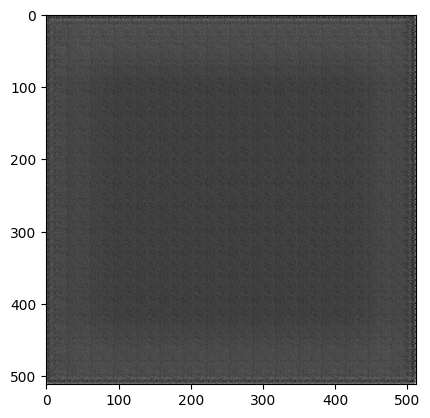

In [ ]:
plt.imshow(decoded[1][0].detach().cpu(), 'gray')

In [ ]:
print(images.min(), images.max(), images.mean())

tensor(-2.1179, device='cuda:0') tensor(2.2318, device='cuda:0') tensor(-1.2666, device='cuda:0')


In [ ]:
decoded

tensor([[[[-0.6806, -0.3772, -0.7754,  ..., -0.7344, -0.5169, -0.7505],
          [-0.9172, -0.6911, -0.9449,  ..., -1.0116, -0.6193, -0.4267],
          [-0.9558, -0.8087, -1.2490,  ..., -1.3099, -1.0095, -0.7718],
          ...,
          [-0.7830, -0.9233, -1.2561,  ..., -1.4313, -0.9586, -0.8250],
          [-0.7749, -0.3397, -0.8544,  ..., -0.6682, -0.6827, -0.2601],
          [-0.6575, -0.5328, -0.8264,  ..., -0.9816, -0.5871, -0.6700]]],


        [[[-0.6806, -0.3771, -0.7754,  ..., -0.7344, -0.5168, -0.7505],
          [-0.9173, -0.6911, -0.9449,  ..., -1.0116, -0.6193, -0.4267],
          [-0.9559, -0.8087, -1.2491,  ..., -1.3098, -1.0095, -0.7718],
          ...,
          [-0.7830, -0.9233, -1.2561,  ..., -1.4313, -0.9586, -0.8250],
          [-0.7749, -0.3397, -0.8544,  ..., -0.6683, -0.6827, -0.2601],
          [-0.6575, -0.5328, -0.8264,  ..., -0.9816, -0.5871, -0.6700]]],


        [[[-0.6806, -0.3772, -0.7754,  ..., -0.7344, -0.5168, -0.7505],
          [-0.9172, -0.691

In [ ]:
loss_MSE(decoded, images)

tensor(0.1698, device='cuda:0')